# Proyecto de Ciencia de Datos - AquaLimpia S.A.

## Análisis exploratorio y reproducible

Este notebook presenta de manera secuencial el análisis desarrollado para AquaLimpia S.A., utilizando el dataset oficial del caso.

El objetivo es analizar el desempeño de las plantas de tratamiento, considerando indicadores asociados a la DBO del efluente, la eficiencia de remoción y el cumplimiento normativo.

El análisis incluye:

- Carga y validación del dataset.
- Preparación de los datos.
- Cálculo de indicadores.
- Comparación entre plantas.
- Análisis de correlación.
- Detección de valores potencialmente atípicos.
- Visualización de resultados.
- Conclusiones principales.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.funciones_analisis import (
    calcular_eficiencia_remocion,
    calcular_correlacion_pearson,
    detectar_atipicos_zscore
)

# Ruta del proyecto
BASE_DIR = Path.cwd()

archivo = BASE_DIR / "dataset_set_A_aguas_residuales.xlsx"

if not archivo.exists():
    raise FileNotFoundError(
        f"No se encontró el dataset en: {archivo}"
    )

# Carga del dataset
df = pd.read_excel(archivo)

print("Dataset cargado correctamente.")
print(f"Registros: {len(df)}")
print(f"Columnas: {len(df.columns)}")

df.head()

Dataset cargado correctamente.
Registros: 200
Columnas: 10


,fecha_registro,planta,caudal_entrada_m3_d,DBO_entrada_mg_L,SST_entrada_mg_L,pH_entrada,energia_aeracion_kWh,lodos_generados_kg_d,DBO_salida_mg_L,cumplimiento_norma
0,2025-08-17,Planta Sur,6562,271,324,7.12,1261.1,440.3,40.0,0
1,2025-09-07,Planta Sur,5336,322,230,7.01,1629.3,561.2,26.8,1
2,2025-07-26,Planta Norte,5755,318,282,6.79,1469.2,441.6,45.2,0
3,2025-10-27,Planta Centro,6840,216,167,7.01,1764.8,560.0,38.0,0
4,2025-09-06,Planta Centro,6803,326,200,7.55,1409.3,654.0,32.1,0


In [2]:
# ==========================================================
# Preparación de los datos
# ==========================================================

df["fecha_registro"] = pd.to_datetime(
    df["fecha_registro"],
    errors="coerce"
)

df = df.sort_values(
    "fecha_registro"
).reset_index(drop=True)

df["eficiencia_remocion_pct"] = calcular_eficiencia_remocion(
    df["DBO_entrada_mg_L"],
    df["DBO_salida_mg_L"]
)

df["estado_cumplimiento"] = df[
    "cumplimiento_norma"
].map(
    {
        1: "Cumple",
        0: "No cumple"
    }
)

print("Preparación de datos finalizada.")
print(
    f"Eficiencia promedio de remoción: "
    f"{df['eficiencia_remocion_pct'].mean():.2f}%"
)

df[
    [
        "fecha_registro",
        "planta",
        "DBO_entrada_mg_L",
        "DBO_salida_mg_L",
        "eficiencia_remocion_pct",
        "estado_cumplimiento"
    ]
].head()

Preparación de datos finalizada.
Eficiencia promedio de remoción: 87.09%


,fecha_registro,planta,DBO_entrada_mg_L,DBO_salida_mg_L,eficiencia_remocion_pct,estado_cumplimiento
0,2025-07-01,Planta Norte,432,79.0,81.712963,No cumple
1,2025-07-02,Planta Norte,235,32.0,86.382979,No cumple
2,2025-07-03,Planta Centro,396,64.9,83.611111,No cumple
3,2025-07-04,Planta Norte,265,24.0,90.943396,No cumple
4,2025-07-05,Planta Centro,209,35.5,83.014354,No cumple


In [3]:
# ==========================================================
# Indicadores generales
# ==========================================================

dbo_salida_promedio = df["DBO_salida_mg_L"].mean()

eficiencia_promedio = df[
    "eficiencia_remocion_pct"
].mean()

cumplimiento_general = (
    df["cumplimiento_norma"].mean() * 100
)

print("INDICADORES GENERALES")
print("-" * 45)

print(
    f"DBO de salida promedio: "
    f"{dbo_salida_promedio:.2f} mg/L"
)

print(
    f"Eficiencia promedio de remoción: "
    f"{eficiencia_promedio:.2f}%"
)

print(
    f"Cumplimiento normativo general: "
    f"{cumplimiento_general:.2f}%"
)


# ==========================================================
# Resumen por planta
# ==========================================================

resumen_por_planta = (
    df.groupby("planta")
    .agg(
        registros=("planta", "size"),
        caudal_promedio=(
            "caudal_entrada_m3_d",
            "mean"
        ),
        dbo_entrada_promedio=(
            "DBO_entrada_mg_L",
            "mean"
        ),
        dbo_salida_promedio=(
            "DBO_salida_mg_L",
            "mean"
        ),
        eficiencia_promedio=(
            "eficiencia_remocion_pct",
            "mean"
        ),
        cumplimiento_pct=(
            "cumplimiento_norma",
            lambda x: x.mean() * 100
        )
    )
    .round(2)
)

resumen_por_planta

INDICADORES GENERALES
---------------------------------------------
DBO de salida promedio: 36.18 mg/L
Eficiencia promedio de remoción: 87.09%
Cumplimiento normativo general: 22.50%


,registros,caudal_promedio,dbo_entrada_promedio,dbo_salida_promedio,eficiencia_promedio,cumplimiento_pct
planta,,,,,,
Planta Centro,75,5112.72,285.19,35.90,87.51,22.67
Planta Norte,71,5287.87,275.85,36.56,86.65,16.90
Planta Sur,54,4684.52,278.80,36.06,87.10,29.63


## Análisis estadístico

Se evalúa la relación entre la DBO de entrada y la DBO de salida mediante el coeficiente de correlación de Pearson. Además, se identifican valores potencialmente atípicos en la DBO de salida mediante el método Z-score.

In [4]:
# ==========================================================
# Correlación de Pearson
# ==========================================================

correlacion, p_valor = calcular_correlacion_pearson(
    df["DBO_entrada_mg_L"],
    df["DBO_salida_mg_L"]
)

print("ANÁLISIS DE CORRELACIÓN")
print("-" * 45)

print(
    f"Correlación de Pearson: "
    f"{correlacion:.3f}"
)

if p_valor < 0.001:
    print("P-valor: < 0.001")
else:
    print(f"P-valor: {p_valor:.4f}")


# ==========================================================
# Detección de valores potencialmente atípicos
# ==========================================================

df["atipico_dbo_salida"] = detectar_atipicos_zscore(
    df["DBO_salida_mg_L"],
    umbral=3.0
)

cantidad_atipicos = int(
    df["atipico_dbo_salida"].sum()
)

print("\nVALORES POTENCIALMENTE ATÍPICOS")
print("-" * 45)

print(
    f"Registros identificados: "
    f"{cantidad_atipicos}"
)

df.loc[
    df["atipico_dbo_salida"],
    [
        "fecha_registro",
        "planta",
        "DBO_entrada_mg_L",
        "DBO_salida_mg_L"
    ]
]

ANÁLISIS DE CORRELACIÓN
---------------------------------------------
Correlación de Pearson: 0.759
P-valor: < 0.001

VALORES POTENCIALMENTE ATÍPICOS
---------------------------------------------
Registros identificados: 2


,fecha_registro,planta,DBO_entrada_mg_L,DBO_salida_mg_L
0,2025-07-01,Planta Norte,432,79.0
194,2025-10-25,Planta Norte,432,76.8


## Visualización de resultados

A continuación, se presentan visualizaciones orientadas a comparar el desempeño de las plantas, analizar la relación entre la DBO de entrada y salida y observar la evolución temporal de la calidad del efluente.

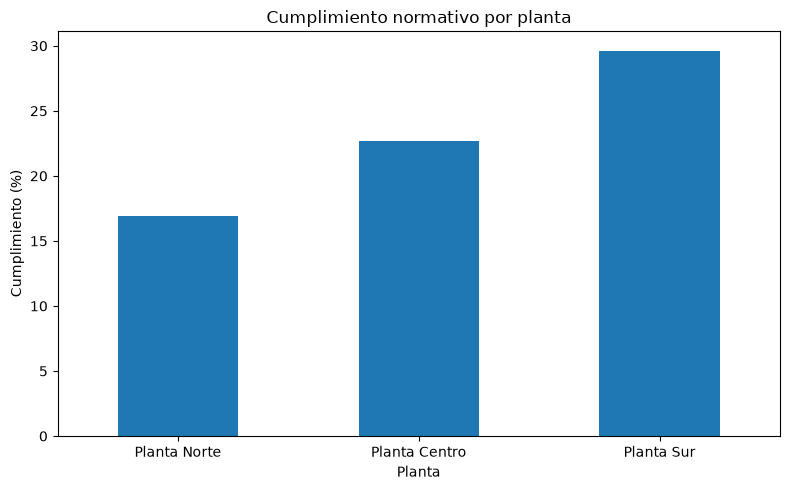

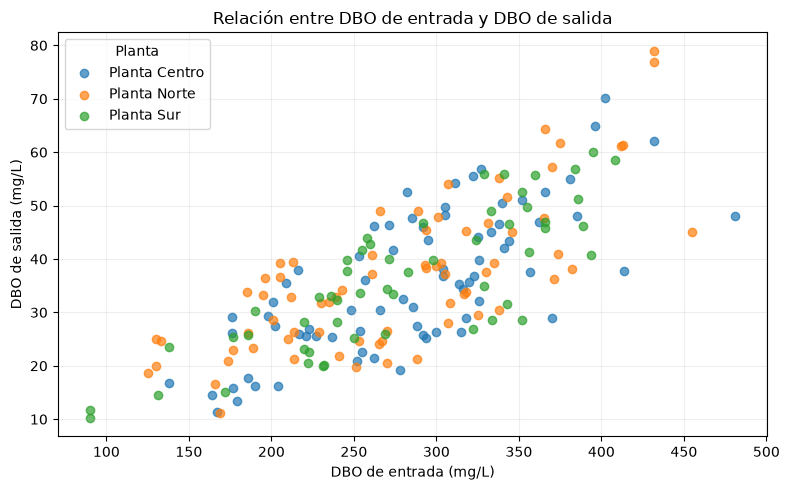

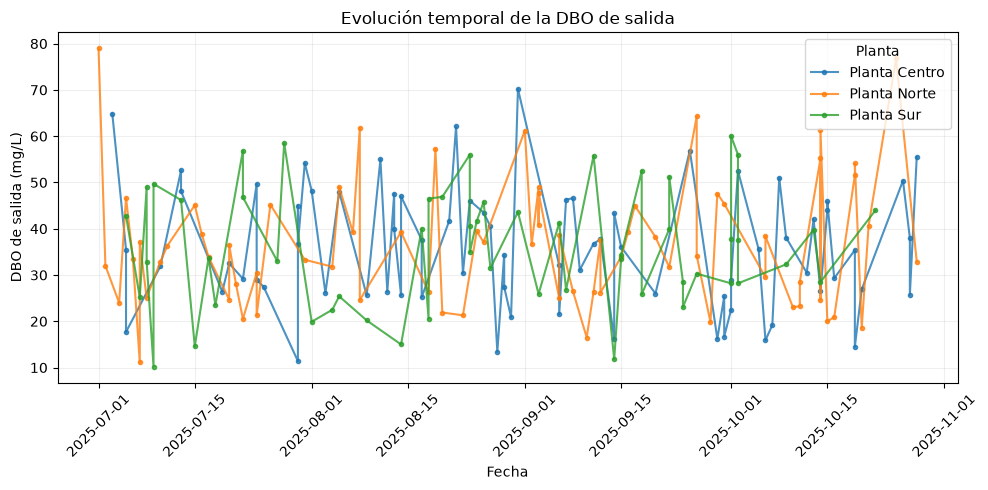

In [5]:
# ==========================================================
# 1. Cumplimiento normativo por planta
# ==========================================================

cumplimiento_planta = (
    df.groupby("planta")["cumplimiento_norma"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

cumplimiento_planta.plot(
    kind="bar"
)

plt.title(
    "Cumplimiento normativo por planta"
)

plt.ylabel(
    "Cumplimiento (%)"
)

plt.xlabel(
    "Planta"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()


# ==========================================================
# 2. Relación entre DBO de entrada y salida
# ==========================================================

plt.figure(figsize=(8, 5))

for planta in sorted(df["planta"].unique()):

    datos_planta = df[
        df["planta"] == planta
    ]

    plt.scatter(
        datos_planta["DBO_entrada_mg_L"],
        datos_planta["DBO_salida_mg_L"],
        label=planta,
        alpha=0.7
    )

plt.title(
    "Relación entre DBO de entrada y DBO de salida"
)

plt.xlabel(
    "DBO de entrada (mg/L)"
)

plt.ylabel(
    "DBO de salida (mg/L)"
)

plt.legend(
    title="Planta"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()
plt.show()


# ==========================================================
# 3. Evolución temporal de la DBO de salida
# ==========================================================

plt.figure(figsize=(10, 5))

for planta in sorted(df["planta"].unique()):

    datos_planta = df[
        df["planta"] == planta
    ].sort_values(
        "fecha_registro"
    )

    plt.plot(
        datos_planta["fecha_registro"],
        datos_planta["DBO_salida_mg_L"],
        marker="o",
        markersize=3,
        label=planta,
        alpha=0.8
    )

plt.title(
    "Evolución temporal de la DBO de salida"
)

plt.xlabel(
    "Fecha"
)

plt.ylabel(
    "DBO de salida (mg/L)"
)

plt.legend(
    title="Planta"
)

plt.grid(
    alpha=0.2
)

plt.xticks(
    rotation=45
)

plt.tight_layout()
plt.show()

## Evaluación de calidad de los datos

Como parte del análisis se revisan aspectos básicos de calidad del dataset, tales como valores nulos, registros duplicados, fechas inválidas, valores de cumplimiento fuera de dominio, valores negativos e inconsistencias entre la DBO de entrada y salida.

In [6]:
# ==========================================================
# Evaluación de calidad de los datos
# ==========================================================

total_nulos = int(df.isnull().sum().sum())

duplicados = int(
    df.duplicated().sum()
)

fechas_invalidas = int(
    df["fecha_registro"].isna().sum()
)

cumplimientos_invalidos = int(
    (
        df["cumplimiento_norma"].notna()
        & ~df["cumplimiento_norma"].isin([0, 1])
    ).sum()
)

columnas_no_negativas = [
    "caudal_entrada_m3_d",
    "DBO_entrada_mg_L",
    "DBO_salida_mg_L",
    "energia_aeracion_kWh",
    "lodos_generados_kg_d"
]

total_negativos = sum(
    int((df[columna] < 0).sum())
    for columna in columnas_no_negativas
)

dbo_inconsistente = int(
    (
        df["DBO_salida_mg_L"]
        > df["DBO_entrada_mg_L"]
    ).sum()
)

resumen_calidad = pd.DataFrame(
    {
        "Indicador": [
            "Valores nulos",
            "Registros duplicados",
            "Fechas inválidas",
            "Valores de cumplimiento inválidos",
            "Valores negativos",
            "DBO salida > DBO entrada",
            "Valores potencialmente atípicos"
        ],
        "Resultado": [
            total_nulos,
            duplicados,
            fechas_invalidas,
            cumplimientos_invalidos,
            total_negativos,
            dbo_inconsistente,
            cantidad_atipicos
        ]
    }
)

resumen_calidad

,Indicador,Resultado
0,Valores nulos,0
1,Registros duplicados,0
2,Fechas inválidas,0
3,Valores de cumplimiento inválidos,0
4,Valores negativos,0
5,DBO salida > DBO entrada,0
6,Valores potencialmente atípicos,2


## Conclusiones

El análisis realizado sobre 200 registros de AquaLimpia S.A. permitió evaluar el desempeño de tres plantas de tratamiento durante el período analizado.

La DBO promedio de salida fue de aproximadamente **36,18 mg/L**, mientras que la eficiencia promedio de remoción alcanzó **87,09 %**. El porcentaje general de cumplimiento normativo fue de **22,50 %**.

A nivel de plantas, la Planta Sur presentó el mayor porcentaje de cumplimiento, mientras que la Planta Norte presentó el menor porcentaje durante el período analizado.

El análisis estadístico mostró una correlación positiva entre la DBO de entrada y la DBO de salida de **r = 0,759**, con **p < 0,001**, indicando una asociación estadísticamente significativa entre ambas variables. Este resultado representa una asociación y no demuestra causalidad.

La evaluación de calidad no identificó valores nulos, registros duplicados, fechas inválidas, valores negativos ni inconsistencias entre la DBO de entrada y salida. Sin embargo, se identificaron **2 registros potencialmente atípicos en la DBO de salida**, los cuales se conservaron debido a que pueden representar condiciones reales del proceso.

En conjunto, el notebook permite reproducir las principales etapas del análisis, desde la preparación del dataset hasta la generación e interpretación de resultados.